In [ ]:
1

Equation verification: True
n=10, h=0.6000, max error = 124.522651
n=20, h=0.3000, max error = 115.693791
n=50, h=0.1200, max error = 77.335956
n=100, h=0.0600, max error = 47.197011


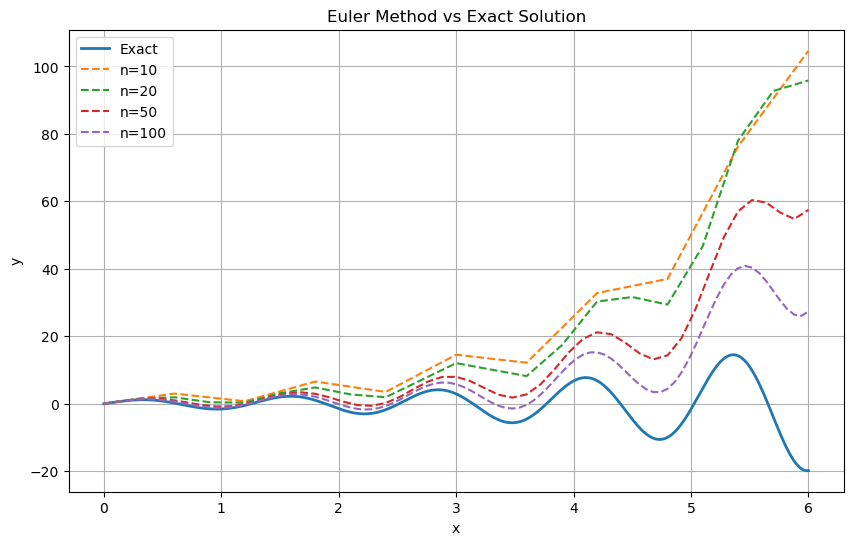

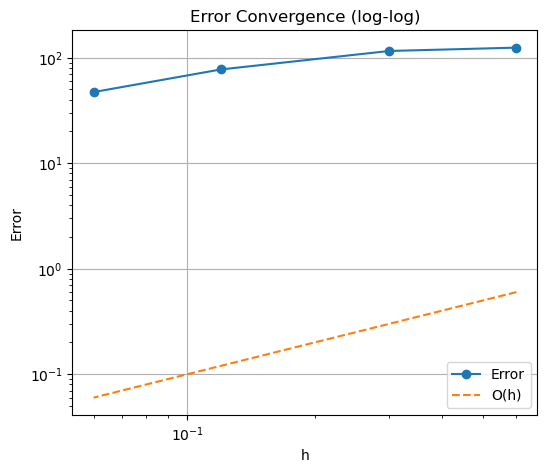


Conclusion:
1. The Euler method demonstrates first-order convergence,
   as the slope in the log-log plot is approximately 1 (O(h)).
2. The numerical solution deviates significantly from the exact solution
   for larger x due to exponential growth of the function.
3. Large step sizes lead to high numerical error,
   and the method becomes unstable on long intervals.
4. Reducing step size improves accuracy,
   but does not fully eliminate instability for rapidly growing solutions.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x_sym = sp.symbols('x')
y_exact_sym = sp.exp(x_sym/2) * sp.sin(5*x_sym)

dy_exact = sp.diff(y_exact_sym, x_sym)
rhs = y_exact_sym - 0.5*sp.exp(x_sym/2)*sp.sin(5*x_sym) + 5*sp.exp(x_sym/2)*sp.cos(5*x_sym)

check = sp.simplify(dy_exact - rhs) == 0
print("Equation verification:", check)

def euler_method(f, x0, y0, x_end, n):
    h = (x_end - x0) / n
    x_vals = [x0]
    y_vals = [y0]

    x = x0
    y = y0

    for _ in range(n):
        y = y + h * f(x, y)
        x = x + h
        x_vals.append(x)
        y_vals.append(y)

    return np.array(x_vals), np.array(y_vals)

def f(x, y):
    return y - 0.5*np.exp(x/2)*np.sin(5*x) + 5*np.exp(x/2)*np.cos(5*x)

x0, y0 = 0, 0
x_end = 6

n_values = [10, 20, 50, 100]
errors = []
h_values = []

x_exact = np.linspace(0, 6, 1000)
y_exact = np.exp(x_exact/2) * np.sin(5*x_exact)

plt.figure(figsize=(10, 6))
plt.plot(x_exact, y_exact, label="Exact", linewidth=2)

for n in n_values:
    x_num, y_num = euler_method(f, x0, y0, x_end, n)
    y_true = np.exp(x_num/2) * np.sin(5*x_num)
    
    error = np.max(np.abs(y_num - y_true))
    errors.append(error)
    h_values.append((x_end - x0)/n)

    print(f"n={n}, h={(x_end-x0)/n:.4f}, max error = {error:.6f}")
    plt.plot(x_num, y_num, '--', label=f"n={n}")

plt.title("Euler Method vs Exact Solution")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(6, 5))
plt.loglog(h_values, errors, 'o-', label='Error')
plt.loglog(h_values, h_values, '--', label='O(h)')

plt.xlabel("h")
plt.ylabel("Error")
plt.title("Error Convergence (log-log)")
plt.legend()
plt.grid()
plt.show()

print("\nConclusion:")
print("1. The Euler method demonstrates first-order convergence,")
print("   as the slope in the log-log plot is approximately 1 (O(h)).")

print("2. The numerical solution deviates significantly from the exact solution")
print("   for larger x due to exponential growth of the function.")

print("3. Large step sizes lead to high numerical error,")
print("   and the method becomes unstable on long intervals.")

print("4. Reducing step size improves accuracy,")
print("   but does not fully eliminate instability for rapidly growing solutions.")

In [ ]:
2

y1(x) =
       ⎛     2⎞
1 - log⎝1 - x ⎠

y2(x) =
x                                 
⌠                                 
⎮       ⎛       ⎛     2⎞⎞         
⎮   2⋅t⋅⎝1 - log⎝1 - t ⎠⎠         
⎮ ───────────────────────── dt + 1
⎮                         2       
⎮    2   ⎛       ⎛     2⎞⎞        
⎮ - t  + ⎝1 - log⎝1 - t ⎠⎠        
⌡                                 
0                                 
------------------------------


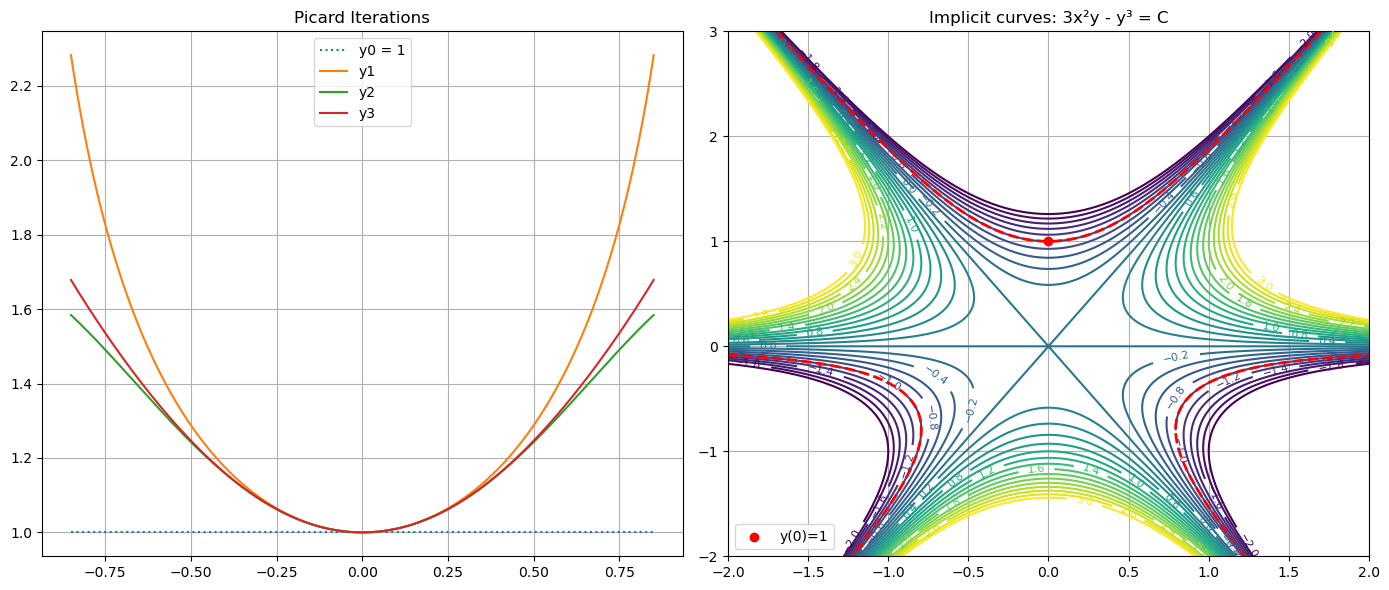

Problem 2 | C = -1


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import quad
import warnings

warnings.filterwarnings('ignore')

t_sym, x_sym = sp.symbols('t x', real=True)
y0_sym = sp.Integer(1)

y1_sym = 1 - sp.log(1 - x_sym**2)
print("y1(x) =")
sp.pprint(y1_sym)

y1_t = y1_sym.subs(x_sym, t_sym)
f1 = 2*t_sym*y1_t / (y1_t**2 - t_sym**2)
y2_sym = 1 + sp.Integral(f1, (t_sym, 0, x_sym))
print("\ny2(x) =")
sp.pprint(y2_sym)
print("-" * 30)

def picard_step(y_prev, x_vals):
    y_new = []
    for x in x_vals:
        def integrand(t):
            y_val = np.interp(t, x_vals, y_prev)
            return (2*t*y_val)/(y_val**2 - t**2)
        val, _ = quad(integrand, 0, x)
        y_new.append(1 + val)
    return np.array(y_new)

x_vals = np.linspace(-0.85, 0.85, 200) 

y0 = np.ones_like(x_vals)
y1 = picard_step(y0, x_vals)
y2 = picard_step(y1, x_vals)
y3 = picard_step(y2, x_vals)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(x_vals, y0, label="y0 = 1", linestyle=':')
plt.plot(x_vals, y1, label="y1")
plt.plot(x_vals, y2, label="y2")
plt.plot(x_vals, y3, label="y3")
plt.legend()
plt.grid()
plt.title("Picard Iterations")

plt.subplot(1, 2, 2)
X, Y = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-2, 3, 400))
F = 3*X**2*Y - Y**3

contour = plt.contour(X, Y, F, levels=np.arange(-2, 3.2, 0.2), cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)
plt.contour(X, Y, F, levels=[-1], colors='red', linewidths=2)
plt.scatter(0, 1, color='red', zorder=5, label='y(0)=1')

plt.title("Implicit curves: 3x²y - y³ = C")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

print("Problem 2 | C =", -1)

In [ ]:
3

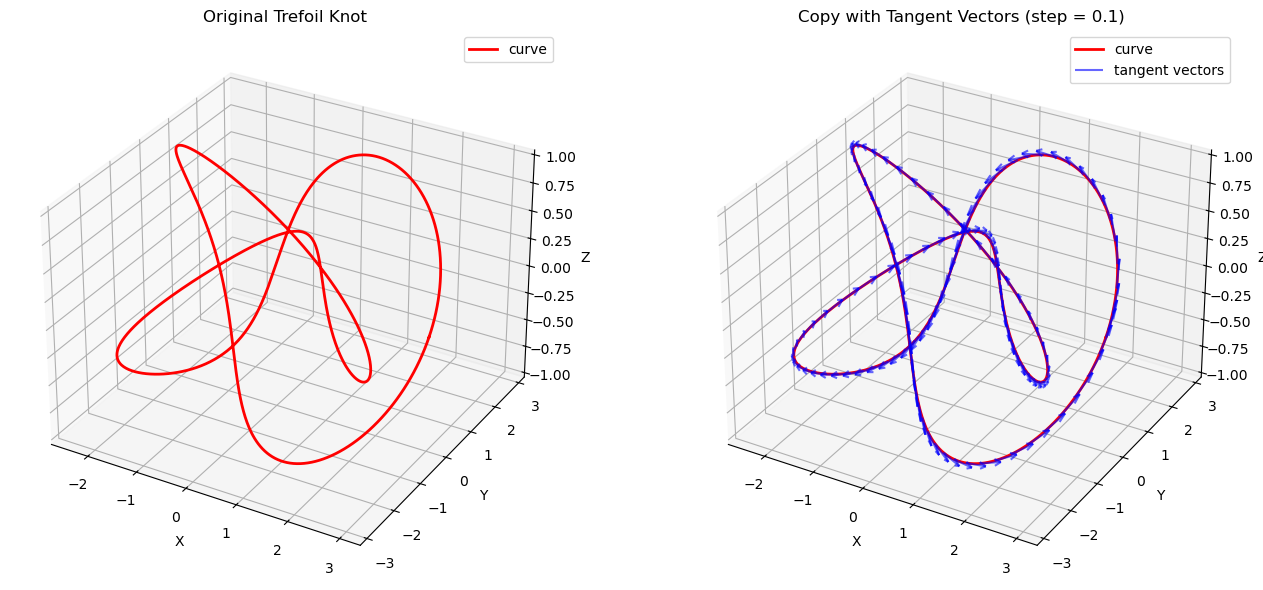

In [12]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 4*np.pi, 1000)

x = (2 + np.cos(1.5*t)) * np.cos(t)
y = (2 + np.cos(1.5*t)) * np.sin(t)
z = np.sin(1.5*t)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot(x, y, z, color='red', linewidth=2, label='curve')
ax1.set_title("Original Trefoil Knot")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot(x, y, z, color='red', linewidth=2, label='curve')

t_tan = np.arange(0, 4*np.pi + 0.05, 0.1)

x_t = (2 + np.cos(1.5*t_tan)) * np.cos(t_tan)
y_t = (2 + np.cos(1.5*t_tan)) * np.sin(t_tan)
z_t = np.sin(1.5*t_tan)

dx = -np.sin(t_tan)*(2 + np.cos(1.5*t_tan)) - 1.5*np.sin(1.5*t_tan)*np.cos(t_tan)
dy =  np.cos(t_tan)*(2 + np.cos(1.5*t_tan)) - 1.5*np.sin(1.5*t_tan)*np.sin(t_tan)
dz =  1.5*np.cos(1.5*t_tan)

ax2.quiver(
    x_t, y_t, z_t,
    dx, dy, dz,
    length=0.4, normalize=True, color='blue', alpha=0.6,
    label='tangent vectors'
)

ax2.set_title("Copy with Tangent Vectors (step = 0.1)")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Z")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
4(A)

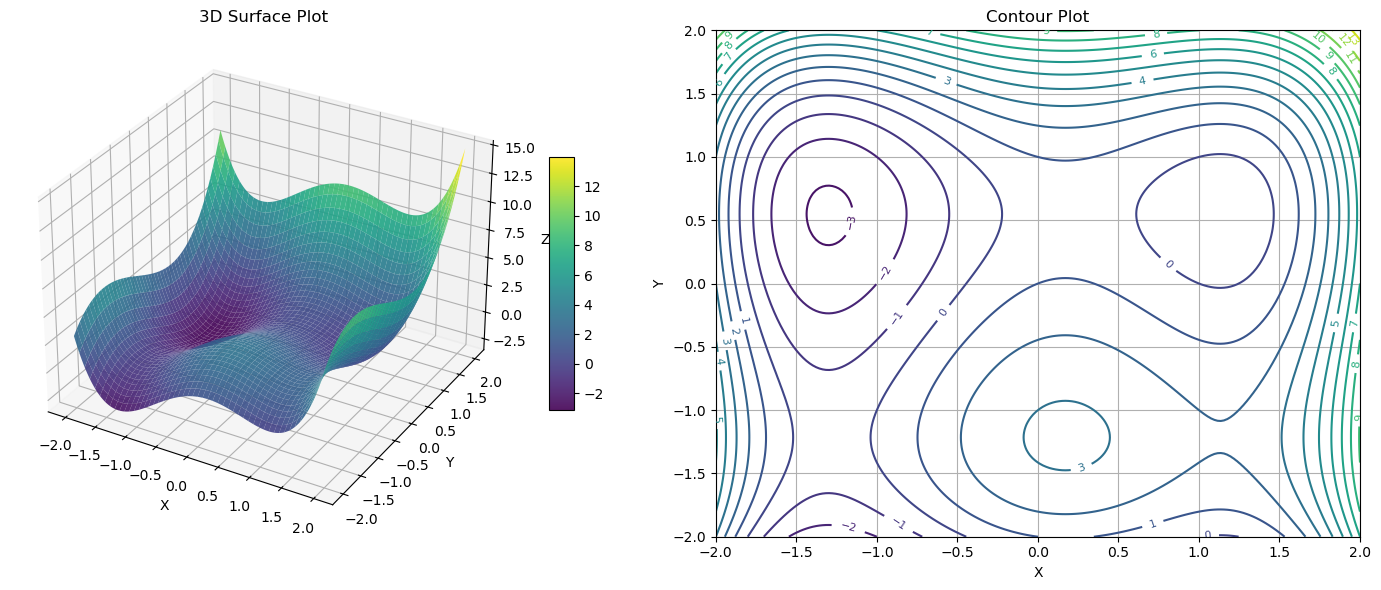

In [11]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2, 2, 200)
y = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x, y)

Z = X**4 + Y**3 - 3*X**2 + Y**2 + X - 2*Y + 1

fig = plt.figure(figsize=(14, 6))

ax = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.9)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

ax.set_title("3D Surface Plot")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax2 = fig.add_subplot(1, 2, 2)
cont = ax2.contour(X, Y, Z, 20, cmap='viridis')
ax2.clabel(cont, inline=True, fontsize=8)

ax2.set_title("Contour Plot")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
4(б)

Problem 4B | Stationary points (x, y):
(0.170, 0.549)
(0.170, -1.215)
(1.131, 0.549)
(1.131, -1.215)
(-1.301, 0.549)
(-1.301, -1.215)


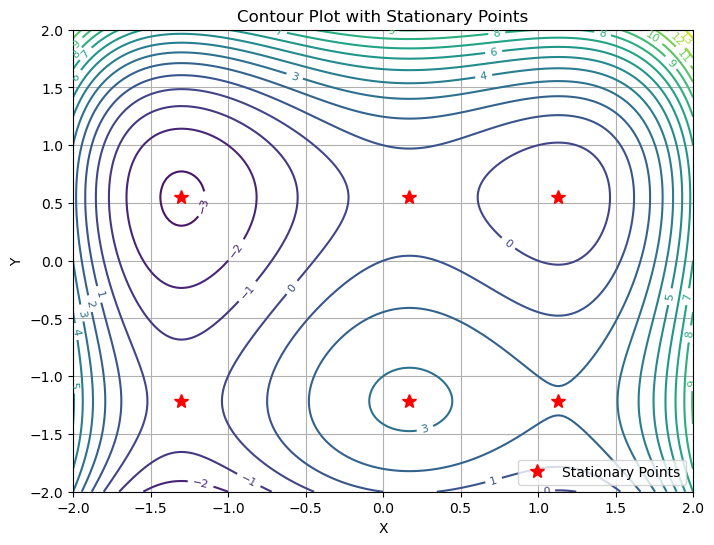

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x_sym, y_sym = sp.symbols('x y')
f_sym = x_sym**4 + y_sym**3 - 3*x_sym**2 + y_sym**2 + x_sym - 2*y_sym + 1

fx = sp.diff(f_sym, x_sym)
fy = sp.diff(f_sym, y_sym)

critical_points = sp.solve([fx, fy], [x_sym, y_sym])

print("Problem 4B | Stationary points (x, y):")
points_numeric = []

for pt in critical_points:
    xn = float(sp.re(pt[0].evalf()))
    yn = float(sp.re(pt[1].evalf()))
    points_numeric.append((xn, yn))
    print(f"({xn:.3f}, {yn:.3f})")

x_val = np.linspace(-2, 2, 200)
y_val = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x_val, y_val)

Z = X**4 + Y**3 - 3*X**2 + Y**2 + X - 2*Y + 1

plt.figure(figsize=(8, 6))

cont = plt.contour(X, Y, Z, 20, cmap='viridis')
plt.clabel(cont, inline=True, fontsize=8)

for idx, (xn, yn) in enumerate(points_numeric):
    label = 'Stationary Points' if idx == 0 else ""
    plt.plot(xn, yn, marker='*', markersize=10, color='red', linestyle='None', label=label)

plt.title("Contour Plot with Stationary Points")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
4(В)

In [9]:
import sympy as sp

x, y = sp.symbols('x y')

f = x**4 + y**3 - 3*x**2 + y**2 + x - 2*y + 1

fx = sp.diff(f, x)
fy = sp.diff(f, y)

fxx = sp.diff(fx, x)
fyy = sp.diff(fy, y)
fxy = sp.diff(fx, y)

critical_points = sp.solve([fx, fy], [x, y], dict=True)

print("Problem 4C | Classification of stationary points:\n")

for pt in critical_points:
    xn = float(sp.re(pt[x].evalf()))
    yn = float(sp.re(pt[y].evalf()))
    
    pt_eval = {x: xn, y: yn}
    
    H = fxx.subs(pt_eval) * fyy.subs(pt_eval) - fxy.subs(pt_eval)**2
    
    val = f.subs(pt_eval)
    
    print(f"Point ({xn:.3f}, {yn:.3f})")
    print(f"f(x,y) = {float(val):.4f}")
    
    H_val = float(H)
    fxx_val = float(fxx.subs(pt_eval))
    
    if H_val > 0:
        if fxx_val > 0:
            print("Type: Local Minimum")
        else:
            print("Type: Local Maximum")
    elif H_val < 0:
        print("Type: Saddle Point")
    else:
        print("Type: Inconclusive")
        
    print("-" * 35)

Problem 4C | Classification of stationary points:

Point (0.170, 0.549)
f(x,y) = 0.4530
Type: Saddle Point
-----------------------------------
Point (0.170, -1.215)
f(x,y) = 3.1967
Type: Local Maximum
-----------------------------------
Point (1.131, 0.549)
f(x,y) = -0.7014
Type: Local Minimum
-----------------------------------
Point (1.131, -1.215)
f(x,y) = 2.0424
Type: Saddle Point
-----------------------------------
Point (-1.301, 0.549)
f(x,y) = -3.1450
Type: Local Minimum
-----------------------------------
Point (-1.301, -1.215)
f(x,y) = -0.4013
Type: Saddle Point
-----------------------------------


In [ ]:
4(Г)

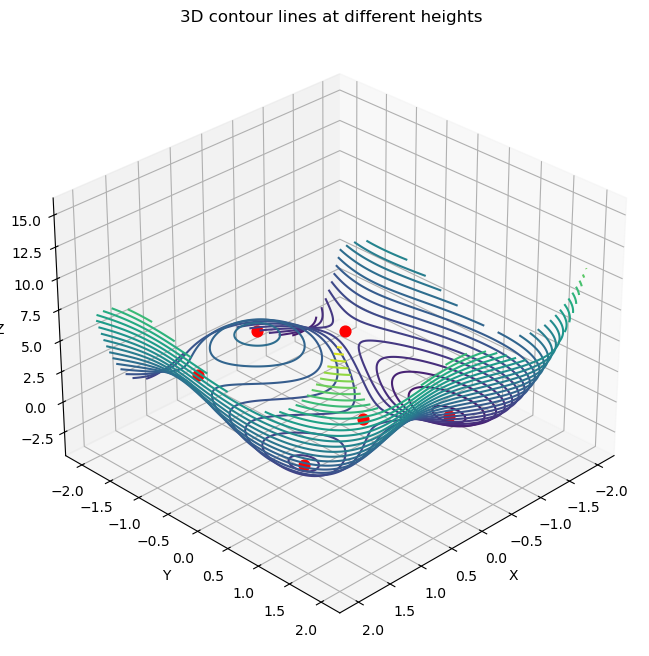

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x, y = sp.symbols('x y')
f = x**4 + y**3 - 3*x**2 + y**2 + x - 2*y + 1

fx = sp.diff(f, x)
fy = sp.diff(f, y)

critical_points = sp.solve([fx, fy], [x, y], dict=True)

points = []
for pt in critical_points:
    xn = float(sp.re(pt[x].evalf()))
    yn = float(sp.re(pt[y].evalf()))
    zn = xn**4 + yn**3 - 3*xn**2 + yn**2 + xn - 2*yn + 1
    points.append((xn, yn, zn))

x_vals = np.linspace(-2, 2, 200)
y_vals = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(x_vals, y_vals)

Z = X**4 + Y**3 - 3*X**2 + Y**2 + X - 2*Y + 1

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.contour(X, Y, Z, levels=30, cmap='viridis')

for (xn, yn, zn) in points:
    ax.scatter(xn, yn, zn, color='red', s=60)

ax.set_title("3D contour lines at different heights")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.view_init(elev=30, azim=45)

plt.show()